In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import glob

import matplotlib.pyplot as plt
import seaborn as sns

import seaborn as sns

from dfmodel import DigitalFamilyBinary
from dpks import QuantMatrix

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial")

In [2]:
def preprocess_data(raw_data, design_matrix):

    quant_matrix = QuantMatrix(
        quantification_file=raw_data[['Protein'] + [sample for sample in design_matrix['sample'].values]].copy(),
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_clinical_data/2023-04-24-UP000005640.fas"
    )

    quant_data = quant_matrix.to_df()

    quant_data = quant_data[~((quant_data["ProteinLabel"].str.startswith("HV")) | (quant_data["ProteinLabel"].str.startswith("LV")) | quant_data["ProteinLabel"].str.startswith("KV"))]
    quant_data = quant_data[~quant_data["ProteinLabel"].str.startswith("IG")]
    quant_data = quant_data[~((quant_data["ProteinLabel"] == "HBA_HUMAN") | (quant_data["ProteinLabel"] == "HBB_HUMAN") | (quant_data["ProteinLabel"] == "HBD_HUMAN") | (quant_data["ProteinLabel"] == "HEMO_HUMAN"))]

    quant_matrix = QuantMatrix(
        quantification_file=quant_data,
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_clinical_data/2023-04-24-UP000005640.fas"
    )

    return quant_matrix

In [3]:
proteomics_data_train = pd.read_csv(
    "protein_train_filtered.tsv",
    sep="\t",
)
clinical_data_train = pd.read_csv(
    "design_matrix_combined.tsv",
    sep='\t'
)
clinical_data_train['sample'] = clinical_data_train['injection']

clinical_data_train = clinical_data_train[clinical_data_train['injection'].isin(proteomics_data_train.columns)].copy().reset_index()


In [4]:
proteomics_data_test = pd.read_csv(
    "protein_ext_filtered.tsv"
    , sep="\t"
)
clinical_data_test = pd.read_csv(
    "design_matrix_ext_hero_combined.tsv",
    sep='\t'
)

#clinical_data_test = clinical_data_test[~clinical_data_test["vasopressor_treatment"].isna()].copy()
clinical_data_test['sample'] = clinical_data_test['injection']
clinical_data_test = clinical_data_test[clinical_data_test['injection'].isin(proteomics_data_test.columns)].copy().reset_index()


In [6]:
clinical_data_train['survival_30_day'] = np.where(clinical_data_train['survival_days'] <= 30, 1, 0)
clinical_data_test['survival_30_day'] = np.where(clinical_data_test['survival_days'] <= 30, 1, 0)

clinical_data_train['vasopressor_treatment'] = np.where(clinical_data_train['vasopressor_treatment'] == 1, 1, 0)
clinical_data_test['vasopressor_treatment'] = np.where(clinical_data_test['vasopressor_treatment'] == 1, 1, 0)


In [7]:
clinical_data_train['sofa_resp_increase_day1'] = clinical_data_train['sofa_resp_day1'] - clinical_data_train['sofa_resp_baseline']
clinical_data_train['sofa_resp_increase_day2'] = clinical_data_train['sofa_resp_day2'] - clinical_data_train['sofa_resp_baseline']
clinical_data_train['sofa_resp_increase_day3'] = clinical_data_train['sofa_resp_day3'] - clinical_data_train['sofa_resp_baseline']

clinical_data_train['sofa_renal_increase_day1'] = clinical_data_train['sofa_renal_day1'] - clinical_data_train['sofa_renal_baseline']
clinical_data_train['sofa_renal_increase_day2'] = clinical_data_train['sofa_renal_day2'] - clinical_data_train['sofa_renal_baseline']
clinical_data_train['sofa_renal_increase_day3'] = clinical_data_train['sofa_renal_day3'] - clinical_data_train['sofa_renal_baseline']

clinical_data_train['sofa_cardiovasc_increase_day1'] = clinical_data_train['sofa_cardiovasc_day1'] - clinical_data_train['sofa_cardiovasc_baseline']
clinical_data_train['sofa_cardiovasc_increase_day2'] = clinical_data_train['sofa_cardiovasc_day2'] - clinical_data_train['sofa_cardiovasc_baseline']
clinical_data_train['sofa_cardiovasc_increase_day3'] = clinical_data_train['sofa_cardiovasc_day3'] - clinical_data_train['sofa_cardiovasc_baseline']

clinical_data_train['sofa_coag_increase_day1'] = clinical_data_train['sofa_coag_day1'] - clinical_data_train['sofa_coag_baseline']
clinical_data_train['sofa_coag_increase_day2'] = clinical_data_train['sofa_coag_day2'] - clinical_data_train['sofa_coag_baseline']
clinical_data_train['sofa_coag_increase_day3'] = clinical_data_train['sofa_coag_day3'] - clinical_data_train['sofa_coag_baseline']

clinical_data_train['sofa_cns_increase_day1'] = clinical_data_train['sofa_cns_day1'] - clinical_data_train['sofa_cns_baseline']
clinical_data_train['sofa_cns_increase_day2'] = clinical_data_train['sofa_cns_day2'] - clinical_data_train['sofa_cns_baseline']
clinical_data_train['sofa_cns_increase_day3'] = clinical_data_train['sofa_cns_day3'] - clinical_data_train['sofa_cns_baseline']

clinical_data_train['sofa_liver_increase_day1'] = clinical_data_train['sofa_liver_day1'] - clinical_data_train['sofa_liver_baseline']
clinical_data_train['sofa_liver_increase_day2'] = clinical_data_train['sofa_liver_day2'] - clinical_data_train['sofa_liver_baseline']
clinical_data_train['sofa_liver_increase_day3'] = clinical_data_train['sofa_liver_day3'] - clinical_data_train['sofa_liver_baseline']


In [8]:
clinical_data_train['resp_dysfunction'] =  np.where(
    clinical_data_train['sofa_resp_increase_day1'] > 1, 1, np.where(
        clinical_data_train['sofa_resp_increase_day2'] > 1, 1, np.where(
            clinical_data_train['sofa_resp_increase_day3'] > 1, 1, 0
        )
    )
)

clinical_data_train['renal_dysfunction'] = np.where(
    clinical_data_train['sofa_renal_increase_day1'] > 0, 1, np.where(
        clinical_data_train['sofa_renal_increase_day2'] > 0, 1, np.where(
            clinical_data_train['sofa_renal_increase_day2'] > 0, 1, 0
        )
    )
)

clinical_data_train['cardiovasc_dysfunction'] = np.where(
    clinical_data_train['sofa_cardiovasc_increase_day1'] > 0, 1, np.where(
        clinical_data_train['sofa_cardiovasc_increase_day2'] > 0, 1, np.where(
            clinical_data_train['sofa_cardiovasc_increase_day3'] > 0, 1, 0
        )
    )

)

clinical_data_train['coag_dysfunction'] = np.where(
    clinical_data_train['sofa_coag_increase_day1'] > 0, 1, np.where(
        clinical_data_train['sofa_coag_increase_day2'] > 0, 1, np.where(
            clinical_data_train['sofa_coag_increase_day3'] > 0, 1, 0
        )
    )
)

clinical_data_train['cns_dysfunction'] = np.where(
     clinical_data_train['sofa_cns_increase_day1'] > 0, 1, np.where(
        clinical_data_train['sofa_cns_increase_day2'] > 0, 1, np.where(
            clinical_data_train['sofa_cns_increase_day3'] > 0, 1, 0
        )
    )
)

clinical_data_train['liver_dysfunction'] = np.where(
     clinical_data_train['sofa_liver_increase_day1'] > 0, 1, np.where(
        clinical_data_train['sofa_liver_increase_day2'] > 0, 1, np.where(
            clinical_data_train['sofa_liver_increase_day3'] > 0, 1, 0
        )
     )
)

clinical_data_train['organ_dysfunction'] = np.where(
    (clinical_data_train['sofa_score_increase_day2'] > 1) & (clinical_data_train['sofa_score_increase_day3'] > 1), 1, 0
)

In [9]:
albumin_cols = []

for col in clinical_data_train:

    if "albumin" in col:

        print(col)

        albumin_cols.append(col)

albumin_0_6h
albumin_0_24h
albumin_24_48h
albumin_0_48h
albumin_48_72h
albumin_0_72h


In [10]:
clinical_data_train['albumin_treatment'] = np.where(clinical_data_train[albumin_cols].sum(axis=1) > 0, 1, 0)

In [11]:
quant_matrix_train = preprocess_data(proteomics_data_train, design_matrix=clinical_data_train)
quant_matrix_test = preprocess_data(proteomics_data_test, design_matrix=clinical_data_test)

In [12]:
training_data, _ = quant_matrix_train.to_ml(feature_column="ProteinLabel", label_column="vasopressor_treatment", comparison=(0, 1))
testing_data, _ = quant_matrix_test.to_ml(feature_column="ProteinLabel", label_column="vasopressor_treatment", comparison=(0, 1))

In [13]:
from sklearn.feature_selection import SelectFdr, f_classif

fdr = SelectFdr(f_classif, alpha=0.1)
fdr.fit(training_data, clinical_data_train['organ_dysfunction'])

,score_func,<function f_c...t 0x3187b13a0>
,alpha,0.1


In [14]:
selected_features = fdr.get_feature_names_out()

In [15]:
from sklearn.preprocessing import StandardScaler

protein_scaler = StandardScaler()
training_data[selected_features] = protein_scaler.fit_transform(training_data[selected_features])

testing_data[selected_features] = protein_scaler.transform(testing_data[selected_features])

In [16]:
from sklearn.neighbors import NeighborhoodComponentsAnalysis

resp_neighborhood = NeighborhoodComponentsAnalysis(
    n_components=1,
)
resp_components = resp_neighborhood.fit_transform(training_data[selected_features], y=clinical_data_train["resp_dysfunction"])

renal_neighborhood = NeighborhoodComponentsAnalysis(n_components=1)
renal_components = renal_neighborhood.fit_transform(training_data[selected_features], y=clinical_data_train["renal_dysfunction"])

cardiovasc_neighborhood = NeighborhoodComponentsAnalysis(n_components=1)
cardiovasc_components = cardiovasc_neighborhood.fit_transform(training_data[selected_features], y=clinical_data_train["cardiovasc_dysfunction"])

coag_neighborhood = NeighborhoodComponentsAnalysis(n_components=1)
coag_components = coag_neighborhood.fit_transform(training_data[selected_features], y=clinical_data_train["coag_dysfunction"])

cns_neighborhood = NeighborhoodComponentsAnalysis(n_components=1)
cns_components = cns_neighborhood.fit_transform(training_data[selected_features], y=clinical_data_train["cns_dysfunction"])

liver_neighborhood = NeighborhoodComponentsAnalysis(n_components=1)
liver_components = liver_neighborhood.fit_transform(training_data[selected_features], y=clinical_data_train["liver_dysfunction"])

In [17]:
resp_components_test = resp_neighborhood.transform(testing_data[selected_features])
renal_components_test = renal_neighborhood.transform(testing_data[selected_features])
cardiovasc_components_test = cardiovasc_neighborhood.transform(testing_data[selected_features])
coag_components_test = coag_neighborhood.transform(testing_data[selected_features])
cns_components_test = cns_neighborhood.transform(testing_data[selected_features])
liver_components_test = liver_neighborhood.transform(testing_data[selected_features])

In [18]:
component_normalizer = StandardScaler()

resp_components = pd.DataFrame(
    resp_components,
    columns=["resp1",],
)
renal_components = pd.DataFrame(
    renal_components,
    columns=["renal1", ],
)
cardiovasc_components = pd.DataFrame(
    cardiovasc_components,
    columns=["car1", ],
)
coag_components = pd.DataFrame(
    coag_components,
    columns=["coag1", ],
)
cns_components = pd.DataFrame(
    cns_components,
    columns=["cns1", ],
)
liver_components = pd.DataFrame(
    liver_components,
    columns=["liv1", ],
)

components = pd.concat(
    [resp_components, renal_components, cardiovasc_components, coag_components, cns_components, liver_components],
    axis=1
)

component_cols = components.columns

In [20]:
components[component_cols] = component_normalizer.fit_transform(components[component_cols])

In [21]:
clinical_data_train[component_cols] = components[component_cols]

In [22]:
combined_columns = component_cols

In [23]:
resp_components_test= pd.DataFrame(
    resp_components_test,
    columns=["resp1", ],
)
renal_components_test = pd.DataFrame(
    renal_components_test,
    columns=["renal1", ],
)
cardiovasc_components_test = pd.DataFrame(
    cardiovasc_components_test,
    columns=["car1", ],
)
coag_components_test = pd.DataFrame(
    coag_components_test,
    columns=["coag1", ],
)
cns_components_test = pd.DataFrame(
    cns_components_test,
    columns=["cns1", ],
)
liver_components_test = pd.DataFrame(
    liver_components_test,
    columns=["liv1", ],
)

components_test = pd.concat(
    [resp_components_test, renal_components_test, cardiovasc_components_test, coag_components_test, cns_components_test, liver_components_test],
    axis=1
)

components_test[component_cols] = component_normalizer.transform(components_test[component_cols])
clinical_data_test[component_cols] = components_test[component_cols]

In [24]:
training_data = clinical_data_train.set_index("injection").join(
    training_data
).reset_index()

testing_data = clinical_data_test.set_index("sample").join(
    testing_data
).reset_index()

In [25]:
vaso_columns = []
for col in clinical_data_train.columns:
    if "vasopressor" in col:

        print(col)

        vaso_columns.append(col)

vasopressor_treatment


In [26]:
from dfmodel import DigitalFamilyBinary

df_estimator = DigitalFamilyBinary(
    n_neighbors=10,
    neighbor_metric="euclidean",
    bootstrap_iterations=1000,
)\

df_estimator.fit(training_data, features=selected_features)

In [27]:

training_data['30 Day Mortality'] = df_estimator.predict(training_data, features=selected_features, target_column="survival_30_day", bootstrap=True)
training_data['ICU'] = df_estimator.predict(training_data, features=selected_features, target_column="critical_care", bootstrap=True)
training_data['Vaso'] = df_estimator.predict(training_data, features=selected_features, target_column="vasopressor_treatment", bootstrap=True)
training_data['Albumin'] = df_estimator.predict(training_data, features=selected_features, target_column="albumin_treatment", bootstrap=True)

training_data['Resp Rate'] = df_estimator.predict(training_data, features=selected_features, target_column="resp_dysfunction", bootstrap=True)
training_data['Renal Rate'] = df_estimator.predict(training_data, features=selected_features, target_column="renal_dysfunction", bootstrap=True)
training_data['Cardio Rate'] = df_estimator.predict(training_data, features=selected_features, target_column="cardiovasc_dysfunction", bootstrap=True)
training_data['Liver Rate'] = df_estimator.predict(training_data, features=selected_features, target_column="liver_dysfunction", bootstrap=True)
training_data['CNS Rate'] = df_estimator.predict(training_data, features=selected_features, target_column="cns_dysfunction", bootstrap=True)
training_data['Coag Rate'] = df_estimator.predict(training_data, features=selected_features, target_column="coag_dysfunction", bootstrap=True)

In [29]:

testing_data['30 Day Mortality'] = df_estimator.predict(testing_data, features=selected_features, target_column="survival_30_day", bootstrap=True)
mortality_results = df_estimator.bootstrap_results_df.copy()

testing_data['ICU'] = df_estimator.predict(testing_data, features=selected_features, target_column="critical_care", bootstrap=True)
icu_results = df_estimator.bootstrap_results_df.copy()

testing_data['Vaso'] = df_estimator.predict(testing_data, features=selected_features, target_column="vasopressor_treatment", bootstrap=True)
vaso_results = df_estimator.bootstrap_results_df.copy()

testing_data['Albumin'] = df_estimator.predict(testing_data, features=selected_features, target_column="albumin_treatment", bootstrap=True)
albumin_results = df_estimator.bootstrap_results_df.copy()

In [30]:
mortality_results.join(
    testing_data
).to_csv(
    "mort_bootstrap_results_df.csv",
)

icu_results.join(
    testing_data
).to_csv(
    "icu_bootstrap_results_df.csv",
)

vaso_results.join(
    testing_data
).to_csv(
    "vaso_bootstrap_results_df.csv",
)

albumin_results.join(
    testing_data
).to_csv(
    "albumin_bootstrap_results_df.csv",
)



In [31]:
from fa2_modified import ForceAtlas2
import matplotlib.pyplot as plt
import networkx as nx

G = df_estimator.network_

positions = nx.forceatlas2_layout(
    G,
    max_iter=1000,
    seed=0,
    #strong_gravity=True,
    dissuade_hubs=True
)

In [32]:
display_columns = [
    "Resp Rate",
    "Renal Rate",
    "Cardio Rate",
    "Liver Rate",
    "CNS Rate",
    "Coag Rate"
]

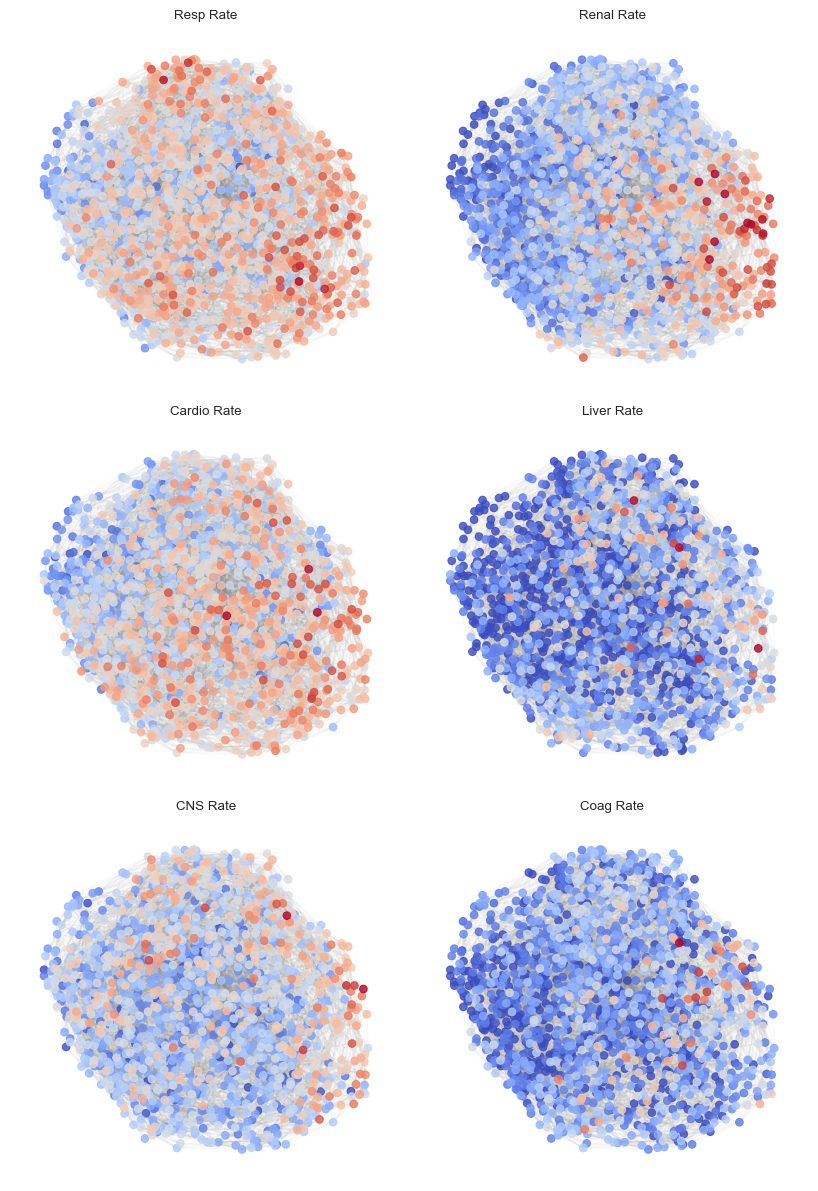

In [33]:
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=3,
    ncols=2,
    #gridspec_kw={'width_ratios': [1, 1, 1, 1, 1, 1, 0.1]}
)


axs = axs.ravel()
for i, col in enumerate(display_columns):

    color_normalizer = MinMaxScaler((0, 1))

    values = MinMaxScaler().fit_transform(training_data[[col]])

    color_map = dict(zip(training_data.index, values))
    ordered_nodes = list(training_data.sort_values(col, ascending=True).index)

    node_colors = [color_map[node] for node in ordered_nodes]

    nx.draw_networkx_nodes(G, positions, node_size=30, node_color=node_colors, nodelist=ordered_nodes, cmap="coolwarm", alpha=0.8, ax=axs[i])
    nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05, ax=axs[i])

    axs[i].axis("off")

    axs[i].set_title(col)


fig.set_size_inches(((8.27), 12))
plt.tight_layout()

fig.savefig(
    "organ_dysfunction_map.pdf",
    bbox_inches="tight",
    transparent=True,
    dpi=300,
)

In [34]:
display_columns = [
    "Albumin",
    "Vaso",
    "ICU",
    "30 Day Mortality",
]

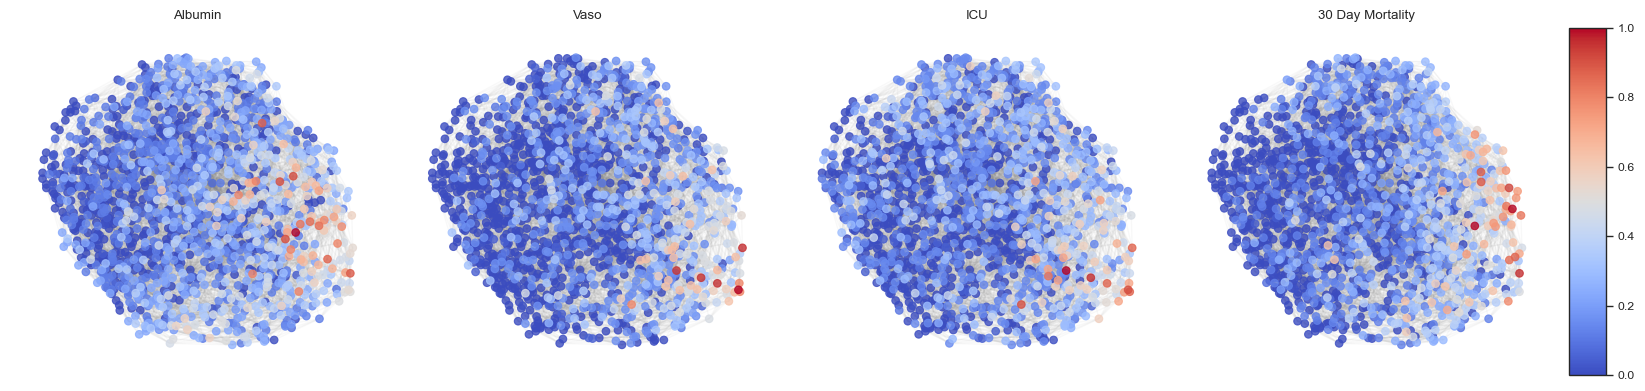

In [35]:
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=1,
    ncols=5,
    gridspec_kw={'width_ratios': [1, 1, 1, 1, 0.1]}
)

for i, col in enumerate(display_columns):

    color_normalizer = MinMaxScaler((0, 1))

    values = MinMaxScaler().fit_transform(training_data[[col]])

    color_map = dict(zip(training_data.index, values))
    ordered_nodes = list(training_data.sort_values(col, ascending=True).index)

    node_colors = [color_map[node] for node in ordered_nodes]

    nx.draw_networkx_nodes(G, positions, node_size=30, node_color=node_colors, nodelist=ordered_nodes, cmap="coolwarm", alpha=0.8, ax=axs[i])
    nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05, ax=axs[i])

    axs[i].axis("off")

    axs[i].set_title(col)



sm = plt.cm.ScalarMappable(cmap="coolwarm")
cbar = fig.colorbar(sm, cax=axs[-1], orientation="vertical")


fig.set_size_inches(((8.27 * 2), 4))
plt.tight_layout()

fig.savefig(
    "vasopressor_map.pdf",
    bbox_inches="tight",
    transparent=True,
    dpi=300,
)

<Axes: xlabel='ICU', ylabel='Vaso'>

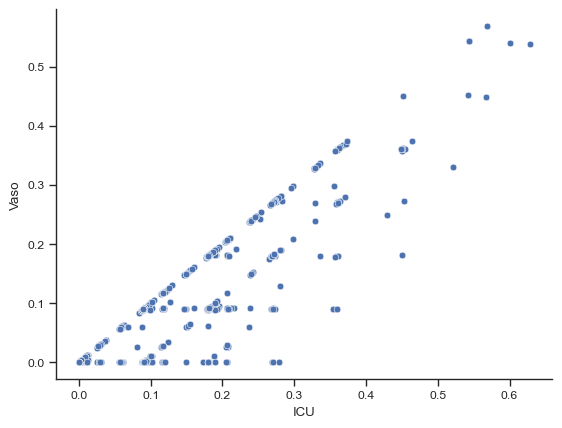

In [36]:
sns.scatterplot(
    data=training_data,
    x="ICU",
    y="Vaso"
)

<Axes: >

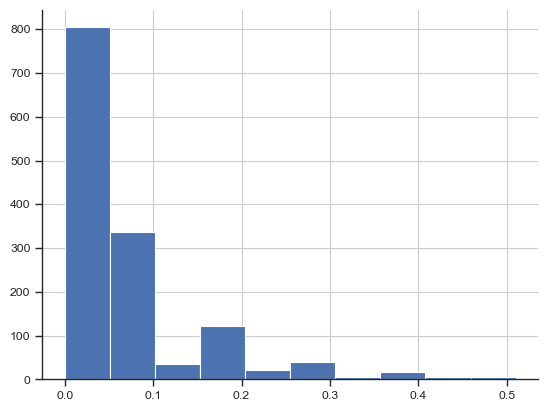

In [37]:
testing_data['Vaso'].hist()

In [38]:
cutoff = testing_data['Vaso'].mean() + testing_data['Vaso'].std()

In [39]:
test = testing_data[testing_data['Vaso'] > 0.0].copy()

In [40]:
test['vasopressor_treatment'].value_counts()

vasopressor_treatment
0    674
1     49
Name: count, dtype: int64

In [41]:
test = testing_data[testing_data['syst_bp_ambulance'] < 120].copy()
test['vasopressor_treatment'].value_counts()

vasopressor_treatment
0    395
1     25
Name: count, dtype: int64

In [42]:
test = testing_data.copy()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0.0 vs. 1.0: t-test independent samples, P_val:6.279e-14 t=-7.606e+00


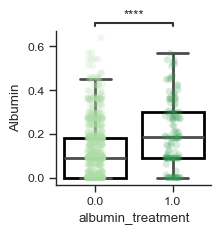

In [43]:
from statannotations.Annotator import Annotator
from scipy.stats import ttest_ind

fig, ax = plt.subplots()

sns.stripplot(
    data=test,
    y="Albumin",
    x="albumin_treatment",
    hue="albumin_treatment",
    ax=ax,
    palette="Greens",
    linewidth=0,
    legend=False,
    alpha=0.2,

)

sns.boxplot(
    data=test,
    y="Albumin",
    x="albumin_treatment",
    hue="albumin_treatment",
    ax=ax,
    #palette="Blues",
    linewidth=2,
    legend=False,
    showfliers=False,
    boxprops={'facecolor':'none', 'edgecolor':'black'}
)


pairs = [(0, 1)]

annot = Annotator(ax, pairs, data=test, x="albumin_treatment", y="Albumin")
annot.configure(test="t-test_ind", text_format="star", loc="outside", verbose=3)
annot.apply_test()
ax, test_results = annot.annotate()

sns.despine()

fig.set_size_inches(2, 2)

fig.savefig(
    "albumin_treatment.pdf",
    bbox_inches="tight",
    dpi=300,
    transparent=True,
)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: t-test independent samples, P_val:2.758e-18 t=-8.843e+00


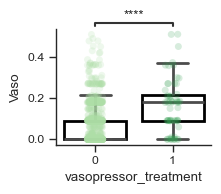

In [44]:
from statannotations.Annotator import Annotator
from scipy.stats import ttest_ind

fig, ax = plt.subplots()

sns.stripplot(
    data=test,
    y="Vaso",
    x="vasopressor_treatment",
    hue="vasopressor_treatment",
    ax=ax,
    palette="Greens",
    linewidth=0,
    legend=False,
    alpha=0.2,

)

sns.boxplot(
    data=test,
    y="Vaso",
    x="vasopressor_treatment",
    hue="vasopressor_treatment",
    ax=ax,
    #palette="Blues",
    linewidth=2,
    legend=False,
    showfliers=False,
    boxprops={'facecolor':'none', 'edgecolor':'black'}
)


pairs = [(0, 1)]

annot = Annotator(ax, pairs, data=test, x="vasopressor_treatment", y="Vaso")
annot.configure(test="t-test_ind", text_format="star", loc="outside", verbose=3)
annot.apply_test()
ax, test_results = annot.annotate()

sns.despine()

fig.set_size_inches(2, 1.5)

fig.savefig(
    "vasopressor_treatment.pdf",
    bbox_inches="tight",
    dpi=300,
    transparent=True,
)

In [45]:
test['syst_bp_ambulance']

0         NaN
1         NaN
2         NaN
3       114.0
4       180.0
        ...  
1391      NaN
1392    132.0
1393    135.0
1394    140.0
1395    130.0
Name: syst_bp_ambulance, Length: 1396, dtype: float64

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: t-test independent samples, P_val:1.771e-03 t=3.133e+00


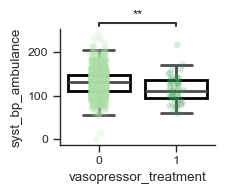

In [46]:
from statannotations.Annotator import Annotator
from scipy.stats import ttest_ind

fig, ax = plt.subplots()

sns.stripplot(
    data=test,
    y="syst_bp_ambulance",
    x="vasopressor_treatment",
    hue="vasopressor_treatment",
    ax=ax,
    palette="Greens",
    linewidth=0,
    legend=False,
    alpha=0.2,

)

sns.boxplot(
    data=test,
    y="syst_bp_ambulance",
    x="vasopressor_treatment",
    hue="vasopressor_treatment",
    ax=ax,
    #palette="Blues",
    linewidth=2,
    legend=False,
    showfliers=False,
    boxprops={'facecolor':'none', 'edgecolor':'black'}
)


pairs = [(0, 1)]

annot = Annotator(ax, pairs, data=test, x="vasopressor_treatment", y="syst_bp_ambulance")
annot.configure(test="t-test_ind", text_format="star", loc="outside", verbose=3)
annot.apply_test()
ax, test_results = annot.annotate()

sns.despine()

fig.set_size_inches(2, 1.5)

fig.savefig(
    "systolic_bp.pdf",
    bbox_inches="tight",
    dpi=300,
    transparent=True,
)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: t-test independent samples, P_val:7.307e-01 t=3.443e-01


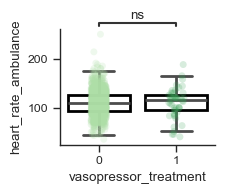

In [47]:
from statannotations.Annotator import Annotator
from scipy.stats import ttest_ind

fig, ax = plt.subplots()

sns.stripplot(
    data=test,
    y="heart_rate_ambulance",
    x="vasopressor_treatment",
    hue="vasopressor_treatment",
    ax=ax,
    palette="Greens",
    linewidth=0,
    legend=False,
    alpha=0.2,

)

sns.boxplot(
    data=test,
    y="heart_rate_ambulance",
    x="vasopressor_treatment",
    hue="vasopressor_treatment",
    ax=ax,
    #palette="Blues",
    linewidth=2,
    legend=False,
    showfliers=False,
    boxprops={'facecolor':'none', 'edgecolor':'black'}
)


pairs = [(0, 1)]

annot = Annotator(ax, pairs, data=test, x="vasopressor_treatment", y="heart_rate_ambulance")
annot.configure(test="t-test_ind", text_format="star", loc="outside", verbose=3)
annot.apply_test()
ax, test_results = annot.annotate()

sns.despine()

fig.set_size_inches(2, 1.5)

fig.savefig(
    "heart_rate.pdf",
    bbox_inches="tight",
    dpi=300,
    transparent=True,
)

In [48]:
organ_dys_components = [
    "resp1",
    "renal1",
    "car1",
    "coag1",
    "cns1",
    "liv1"
]

In [49]:
melted = testing_data[organ_dys_components + ["vasopressor_treatment"]].melt(
    id_vars="vasopressor_treatment",
    value_vars=organ_dys_components,
)

In [50]:
melted

,vasopressor_treatment,variable,value
0,0,resp1,0.235475
1,0,resp1,-0.541900
2,0,resp1,0.056809
3,0,resp1,-0.639668
4,0,resp1,0.357845
...,...,...,...
8371,0,liv1,0.444248
8372,0,liv1,0.444221
8373,0,liv1,-0.589923
8374,0,liv1,-0.069612


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

renal1_0 vs. renal1_1: t-test independent samples, P_val:1.132e-11 t=-6.846e+00
resp1_0 vs. resp1_1: t-test independent samples, P_val:3.815e-06 t=-4.640e+00
car1_0 vs. car1_1: t-test independent samples, P_val:1.125e-10 t=-6.499e+00
coag1_0 vs. coag1_1: t-test independent samples, P_val:8.735e-06 t=-4.463e+00
cns1_0 vs. cns1_1: t-test independent samples, P_val:8.615e-04 t=-3.340e+00
liv1_0 vs. liv1_1: t-test independent samples, P_val:5.348e-05 t=-4.052e+00


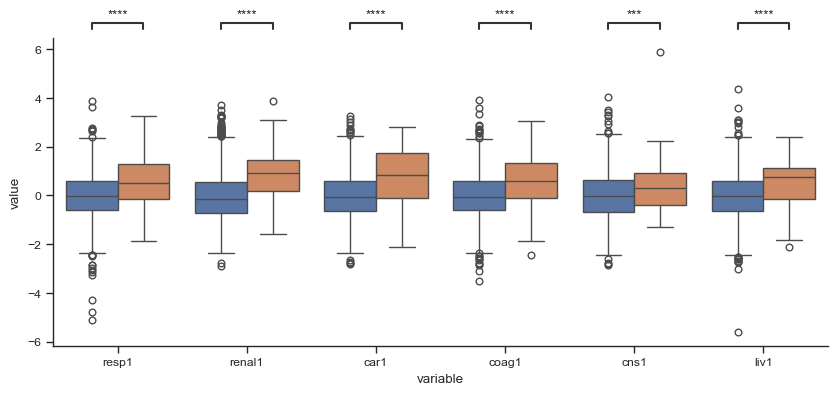

In [51]:
fig, ax = plt.subplots()

sns.boxplot(
    data=melted,
    x="variable",
    y="value",
    hue="vasopressor_treatment",
    ax=ax,
    legend=False,
)


pairs = [
    (("resp1", 0), ("resp1", 1)),
    (("renal1", 0), ("renal1", 1)),
    (("car1", 0), ("car1", 1)),
    (("coag1", 0), ("coag1", 1)),
    (("cns1", 0), ("cns1", 1)),
    (("liv1", 0), ("liv1", 1))

]

annot = Annotator(ax, pairs, data=melted, x="variable", y="value", hue="vasopressor_treatment")
annot.configure(test="t-test_ind", text_format="star", loc="outside", verbose=3)
annot.apply_test()
ax, test_results = annot.annotate()

sns.despine(fig=fig, ax=ax)
fig.set_size_inches((10, 4))

In [52]:
training_data['vaso_label'] = training_data['vasopressor_treatment']#np.where(training_data['Vaso'] > 0, 1, 0)

In [53]:
from sklearn.metrics import balanced_accuracy_score, precision_score, roc_auc_score, recall_score, f1_score

balanced_accuracy_score(testing_data['vasopressor_treatment'], np.where(testing_data['Vaso'] > 0.0, 1, 0)), recall_score(testing_data['vasopressor_treatment'], np.where(testing_data['Vaso'] > 0.0, 1, 0)), precision_score(testing_data['vasopressor_treatment'], np.where(testing_data['Vaso'] > 0.0, 1, 0))

(0.6705453327148085, 0.8448275862068966, 0.0677731673582296)

In [54]:
from sklearn.metrics import class_likelihood_ratios

class_likelihood_ratios(testing_data['vasopressor_treatment'], np.where(testing_data['Vaso'] > 0.3, 1, 0))

(5.767241379310345, 0.8981047644116873)

In [55]:
testing_data[testing_data['Vaso'] > 0.0]['vasopressor_treatment'].value_counts()

vasopressor_treatment
0    674
1     49
Name: count, dtype: int64

In [56]:
subset = testing_data.copy()
subset['vasopressor_treatment'].value_counts()

vasopressor_treatment
0    1338
1      58
Name: count, dtype: int64

In [57]:
subset.loc[subset['syst_bp_ambulance'] == 0.0, 'syst_bp_ambulance'] = np.nan

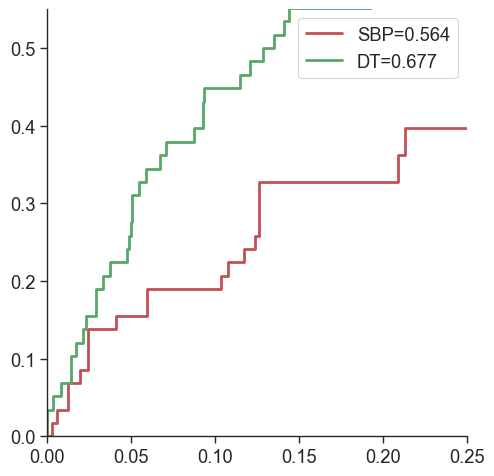

In [58]:
from sklearn.metrics import RocCurveDisplay, roc_curve
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import roc_auc_score


custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial", font_scale=1.5)

fig, ax = plt.subplots(figsize=(5, 5))

subset['SBP_i'] = SimpleImputer().fit_transform(subset[['syst_bp_ambulance']])
#subset['SBP_i'] = StandardScaler().fit_transform(subset[['SBP_i']])

subset['SBP'] = 1 / subset["SBP_i"]
subset['Vaso_t'] = MinMaxScaler().fit_transform(subset[['Vaso']])


sbp_fpr, sbp_tpr, sbp_thresholds = roc_curve(subset['vasopressor_treatment'], subset['SBP'])
sbp_roc = roc_auc_score(
    y_true=subset['vasopressor_treatment'],
    y_score=subset['SBP'],
    max_fpr=0.25,
)


dt_fpr, dt_tpr, dt_thresholds = roc_curve(subset['vasopressor_treatment'], subset['Vaso'])
dt_roc = roc_auc_score(
    y_true=subset['vasopressor_treatment'],
    y_score=subset['Vaso'],
    max_fpr=0.25,
)

ax.step(sbp_fpr, sbp_tpr, color='r', label=f'SBP={round(sbp_roc, 3)}', lw=2)
ax.step(dt_fpr, dt_tpr, color='g', label=f'DT={round(dt_roc, 3)}', lw=2)

plt.legend(loc='best')
plt.tight_layout()

sns.despine()
ax.set_xlim((0, 0.25))
ax.set_ylim((0, 0.55))
#fig.set_size_inches((10, 5))

fig.savefig(
    "roc_auc.pdf",
    bbox_inches="tight",
    dpi=300,
    transparent=True,
)

In [59]:
(dt_roc  - sbp_roc ) / sbp_roc

0.19900021781364946

In [60]:
sbp_thresholds[sbp_fpr <= 0.25][-1]

0.009174311926605505

In [61]:
training_data.to_csv(
    "train_vaso_results.tsv",
    sep="\t",
    index=False,
)

testing_data.to_csv(
    "test_vaso_results.tsv",
    sep="\t",
    index=False,
)

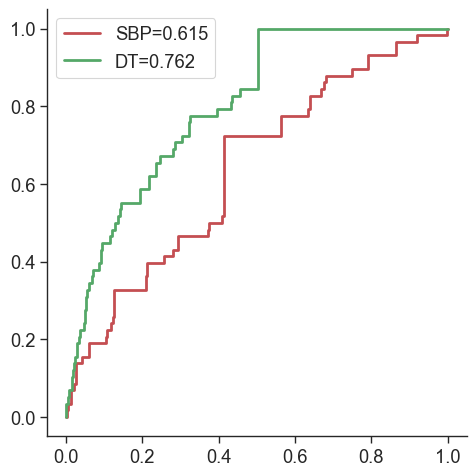

In [62]:
from sklearn.metrics import RocCurveDisplay, roc_curve
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import roc_auc_score


custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial", font_scale=1.5)

fig, ax = plt.subplots(figsize=(5, 5))

subset['SBP_i'] = SimpleImputer().fit_transform(subset[['syst_bp_ambulance']])
#subset['SBP_i'] = StandardScaler().fit_transform(subset[['SBP_i']])

subset['SBP'] = 1 / subset["SBP_i"]
subset['Vaso_t'] = MinMaxScaler().fit_transform(subset[['Vaso']])


sbp_fpr, sbp_tpr, sbp_thresholds = roc_curve(subset['vasopressor_treatment'], subset['SBP'])
sbp_roc = roc_auc_score(
    y_true=subset['vasopressor_treatment'],
    y_score=subset['SBP'],
    max_fpr=1,
)


dt_fpr, dt_tpr, dt_thresholds = roc_curve(subset['vasopressor_treatment'], subset['Vaso'])
dt_roc = roc_auc_score(
    y_true=subset['vasopressor_treatment'],
    y_score=subset['Vaso'],
    max_fpr=1,
)

ax.step(sbp_fpr, sbp_tpr, color='r', label=f'SBP={round(sbp_roc, 3)}', lw=2)
ax.step(dt_fpr, dt_tpr, color='g', label=f'DT={round(dt_roc, 3)}', lw=2)

plt.legend(loc='best')
plt.tight_layout()

sns.despine()
#ax.set_xlim((0, 0.25))
#ax.set_ylim((0, 0.55))
#fig.set_size_inches((10, 5))

fig.savefig(
    "roc_auc.pdf",
    bbox_inches="tight",
    dpi=300,
    transparent=True,
)

In [63]:
(dt_roc - sbp_roc) / sbp_roc

0.2386368396799462

In [64]:
3

3

In [65]:
weight_scaler = MinMaxScaler((0, 1))

resp_weights = pd.DataFrame(
    {
        "Weight": np.abs(resp_neighborhood.components_.ravel()),
        "Feature": resp_neighborhood.feature_names_in_
    }
)
resp_weights['Label'] = "Respiratory"
resp_weights['Weight'] = resp_weights['Weight'] / resp_weights['Weight'].sum()
resp_weights.sort_values("Weight", ascending=False, inplace=True)
resp_weights

,Weight,Feature,Label
67,0.031167,PSPB_HUMAN,Respiratory
143,0.019227,GAPR1_HUMAN,Respiratory
47,0.018957,VCAM1_HUMAN,Respiratory
63,0.017217,FGL1_HUMAN,Respiratory
29,0.016992,HGFA_HUMAN,Respiratory
...,...,...,...
62,0.000258,IBP6_HUMAN,Respiratory
14,0.000255,FCGBP_HUMAN,Respiratory
28,0.000149,A2GL_HUMAN,Respiratory
0,0.000141,FIBA_HUMAN,Respiratory


In [66]:
renal_weights = pd.DataFrame(
    {
        "Weight": np.abs(renal_neighborhood.components_.ravel()),
        "Feature": renal_neighborhood.feature_names_in_
    }
).sort_values("Weight", ascending=False)
renal_weights['Label'] = "Renal"
renal_weights['Weight'] = renal_weights['Weight'] / renal_weights['Weight'].sum()
renal_weights

,Weight,Feature,Label
138,0.030137,CYTC_HUMAN,Renal
79,0.029381,B2MG_HUMAN,Renal
100,0.018415,PHLD_HUMAN,Renal
160,0.017809,ACTBL_HUMAN,Renal
28,0.017761,A2GL_HUMAN,Renal
...,...,...,...
76,0.000306,APOA2_HUMAN,Renal
112,0.000302,AMPN_HUMAN,Renal
21,0.000230,SAA4_HUMAN,Renal
46,0.000229,ITIH3_HUMAN,Renal


In [67]:
liver_weights = pd.DataFrame(
    {
        "Weight": np.abs(liver_neighborhood.components_.ravel()),
        "Feature": liver_neighborhood.feature_names_in_
    }
).sort_values("Weight", ascending=False)
liver_weights['Label'] = "Liver"
liver_weights['Weight'] = liver_weights['Weight'] / liver_weights['Weight'].sum()
liver_weights

,Weight,Feature,Label
148,0.024555,MA1A1_HUMAN,Liver
112,0.020380,AMPN_HUMAN,Liver
79,0.019505,B2MG_HUMAN,Liver
149,0.018108,NRP1_HUMAN,Liver
115,0.018026,CATB_HUMAN,Liver
...,...,...,...
111,0.000067,CO6A1_HUMAN,Liver
156,0.000060,PPIA_HUMAN,Liver
86,0.000036,CALM1_HUMAN,Liver
155,0.000028,SPA11_HUMAN,Liver


In [68]:
coag_weights = pd.DataFrame(
    {
        "Weight": np.abs(coag_neighborhood.components_.ravel()),
        "Feature": coag_neighborhood.feature_names_in_
    }
).sort_values("Weight", ascending=False)
coag_weights["Label"] = "Coagulation"
coag_weights['Weight'] = coag_weights['Weight'] / coag_weights['Weight'].sum()
coag_weights.head(20)

,Weight,Feature,Label
47,0.020670,VCAM1_HUMAN,Coagulation
101,0.018446,SAA1_HUMAN,Coagulation
78,0.018252,PROF1_HUMAN,Coagulation
49,0.017945,CBPB2_HUMAN,Coagulation
158,0.016089,ENPL_HUMAN,Coagulation
69,0.015584,CNDP1_HUMAN,Coagulation
153,0.015256,APOC4_HUMAN,Coagulation
55,0.014812,C163A_HUMAN,Coagulation
36,0.014275,PROC_HUMAN,Coagulation
146,0.013822,VASN_HUMAN,Coagulation


In [69]:
cns_weights = pd.DataFrame(
    {
        "Weight": np.abs(cns_neighborhood.components_.ravel()),
        "Feature": cns_neighborhood.feature_names_in_
    }
).sort_values("Weight", ascending=False)
cns_weights['Label'] = "CNS"
cns_weights['Weight'] = cns_weights['Weight'] / cns_weights['Weight'].sum()
cns_weights.head(20)

,Weight,Feature,Label
51,0.028888,CLUS_HUMAN,CNS
6,0.019723,GELS_HUMAN,CNS
152,0.017661,ANGT_HUMAN,CNS
35,0.016139,PEDF_HUMAN,CNS
84,0.014837,PIGR_HUMAN,CNS
20,0.014766,LYSC_HUMAN,CNS
10,0.013919,APOA4_HUMAN,CNS
103,0.013449,TETN_HUMAN,CNS
38,0.013233,ITIH1_HUMAN,CNS
90,0.013041,FBLN3_HUMAN,CNS


In [70]:
cardio_weights = pd.DataFrame(
    {
        "Weight": np.abs(cardiovasc_neighborhood.components_.ravel()),
        "Feature": cardiovasc_neighborhood.feature_names_in_
    }
).sort_values("Weight", ascending=False)
cardio_weights["Label"] = "Cardio"
cardio_weights['Weight'] = cardio_weights['Weight'] / cardio_weights['Weight'].sum()
cardio_weights.head(20)

,Weight,Feature,Label
3,0.037178,VWF_HUMAN,Cardio
34,0.022209,PLSL_HUMAN,Cardio
138,0.021272,CYTC_HUMAN,Cardio
60,0.019080,CFAD_HUMAN,Cardio
31,0.018037,A1AT_HUMAN,Cardio
111,0.018017,CO6A1_HUMAN,Cardio
63,0.017370,FGL1_HUMAN,Cardio
71,0.017030,IBP2_HUMAN,Cardio
89,0.015809,FBLN5_HUMAN,Cardio
38,0.015799,ITIH1_HUMAN,Cardio


In [71]:
organ_weights = pd.concat(
    [
        resp_weights,
        renal_weights,
        liver_weights,
        coag_weights,
        cns_weights,
        cardio_weights
    ],
    ignore_index=True
)
organ_weights.to_csv(
    "organ_dysfunction_weights.tsv",
    sep="\t",
)